In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import get_dataset, prepare_df
from src.pipeline import get_preprocessor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from src.metrics import metrics
import joblib

In [2]:
df = get_dataset()

In [3]:
X_train, X_test, y_train, y_test = prepare_df(df)

In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(5634, 19)
(5634,)
(1409, 19)
(1409,)


In [5]:
preprocessor = get_preprocessor()

In [6]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [7]:
params_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_features": ["sqrt", "log2", 0.2, 0.3],
    "model__bootstrap": [True],
    "model__max_depth": [None, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 10],
    "model__criterion": ["entropy", "gini"]
}

In [8]:
random_search = RandomizedSearchCV(pipe, param_distributions=params_grid, random_state=42, scoring="f1", verbose=1, n_jobs=1)

In [9]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__criterion': ['entropy', 'gini'], 'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

Accuracy score: 0.808374733853797
recall score: 0.5267379679144385
precision score: 0.6793103448275862
f1 score: 0.5933734939759037
ROC-AUC score: 0.8546242475909995
Classification Report
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



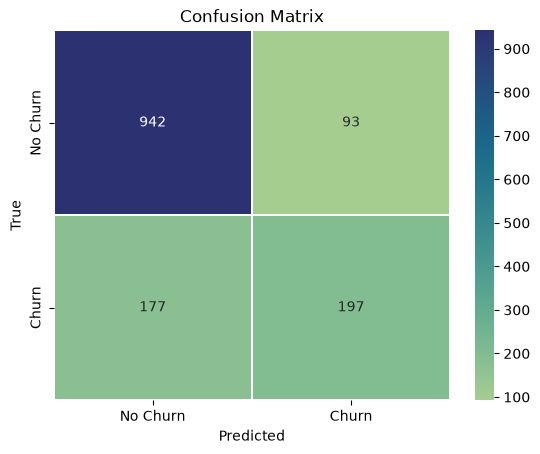

In [10]:
y_pred = random_search.predict(X_test)
y_pred_proba = random_search.predict_proba(X_test)
metrics(y_test, y_pred, y_pred_proba[:, 1])

In [11]:
random_search.best_params_

{'model__n_estimators': 500,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 10,
 'model__max_features': 0.2,
 'model__max_depth': 10,
 'model__criterion': 'gini',
 'model__bootstrap': True}

Accuracy score: 0.8356407525736599
recall score: 0.577257525083612
precision score: 0.7458945548833189
f1 score: 0.6508295625942685
ROC-AUC score: 0.9051121520474544
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      4139
           1       0.75      0.58      0.65      1495

    accuracy                           0.84      5634
   macro avg       0.80      0.75      0.77      5634
weighted avg       0.83      0.84      0.83      5634



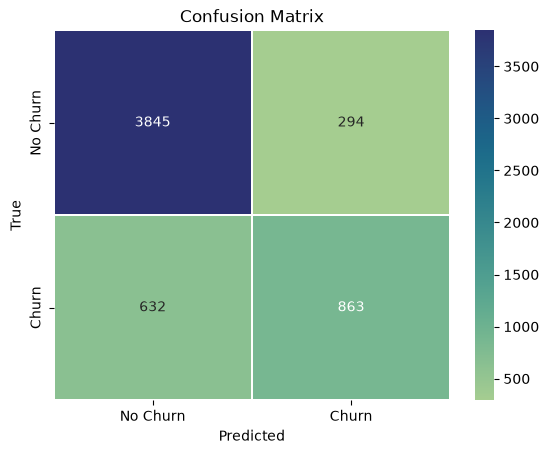

In [12]:
y_pred_train = random_search.predict(X_train)
y_pred_train_proba = random_search.predict_proba(X_train)
metrics(y_train, y_pred_train, y_pred_train_proba[:, 1])

In [13]:
joblib.dump(random_search, "models/randomforest.joblib")

['models/randomforest.joblib']

In [14]:
model = joblib.load("models/randomforest.joblib")

Accuracy score: 0.808374733853797
recall score: 0.5267379679144385
precision score: 0.6793103448275862
f1 score: 0.5933734939759037
ROC-AUC score: 0.8546242475909995
Classification Report
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



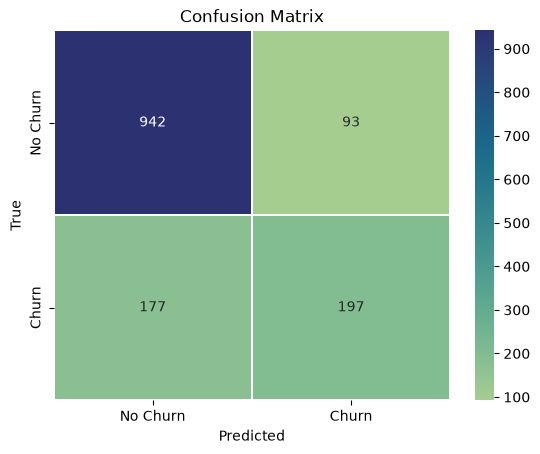

In [15]:
y_pred1 = model.predict(X_test)
y_pred_proba1 = model.predict_proba(X_test)
metrics(y_test, y_pred1, y_pred_proba1[:, 1])